In [11]:
import sys
sys.path.append('..')

from src.visualization import generate_contribution_pie_chart
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import (Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate,
                           CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense)
from src.config import variable_names
from src.analysis import stochastic_contribution_analysis
from matplotlib import pyplot as plt

In [23]:
advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=6.8, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
cpa = CostPerAcquisition(min_value=12, max_value=36)
rent = Rent(min_value=1000, max_value=2000)
tax_rate = TaxRate()

cpa = CostPerAcquisition(min_value=12, max_value=36)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
render_fee = RenderFee(expected_value=600, min_value=500, max_value=800)
travel_fee = TravelFee(min_value=400, max_value=1000)

variables = {variable_names.DEAL_ORDERS: orders,
             variable_names.COST_ADVERTISING: advertising_budget,
             variable_names.COST_CPA: cpa,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
advertising_efficiency_model = AdvertisingEfficiencyModel()
profit_model = ProfitModel()

In [24]:
contributions = stochastic_contribution_analysis(variables=variables,
                                                 breakdown_metrics=[variable_names.COST_ADVERTISING, variable_names.COST_COGS],
                                                 model_pipeline=[cogs_model, revenue_model, cost_model,
                                                                 expense_model,depreciation_model,
                                                                 capital_expenditure_model, profit_model],
                                                 shuffled_inputs=[variable_names.DEAL_PURCHASING_PRICE,
                                                                  variable_names.DEAL_SELLING_PRICE,
                                                                  variable_names.COST_ADVERTISING,
                                                                  variable_names.COST_CONVERSION_RATE,
                                                                  variable_names.COST_CPA],
                                                 sample_size=100)
print(contributions)

{'AdvertisingCost': 20647.797891000002, 'Cogs': 113500.36230000001}


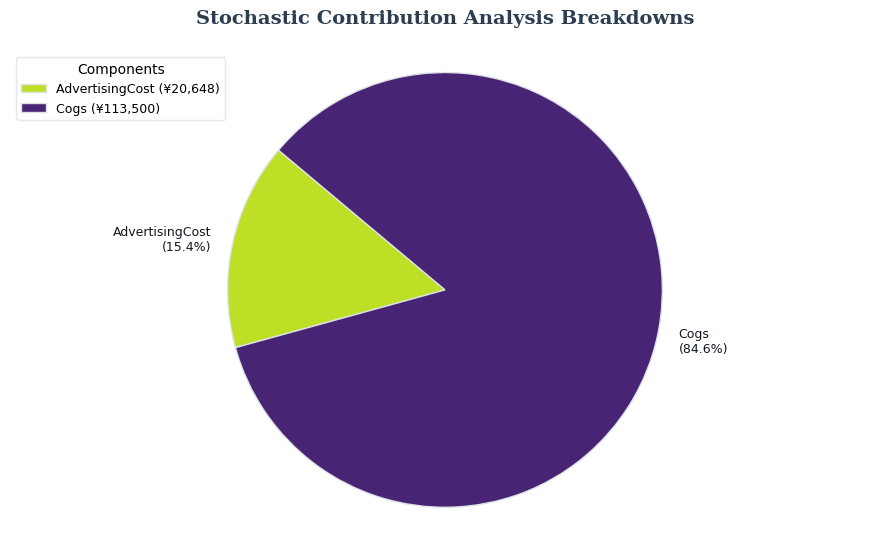

In [25]:
fig = generate_contribution_pie_chart(contributions)
plt.show()

In [30]:
variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.COST_ADVERTISING: advertising_budget,
             variable_names.COST_CPA: cpa,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
             variable_names.EXPENSE_MONTHLY_RENT: rent,
             variable_names.FINANCE_TAX_RATE: tax_rate,
             variable_names.EXPENSE_RENDER_FEE: render_fee,
             variable_names.EXPENSE_TRAVEL_FEE: travel_fee}

contributions_with_expense = stochastic_contribution_analysis(variables=variables,
                                                 breakdown_metrics=[variable_names.COST_ADVERTISING, variable_names.COST_COGS, variable_names.EXPENSE],
                                                 model_pipeline=[advertising_efficiency_model, cogs_model, revenue_model, cost_model,
                                                                 expense_model,depreciation_model,
                                                                 capital_expenditure_model, profit_model],
                                                 shuffled_inputs=[variable_names.DEAL_PURCHASING_PRICE,
                                                                  variable_names.DEAL_SELLING_PRICE,
                                                                  variable_names.COST_ADVERTISING,
                                                                  variable_names.COST_CONVERSION_RATE,
                                                                  variable_names.EXPENSE_MONTHLY_RENT,
                                                                  variable_names.COST_CONVERSION_RATE,
                                                                  variable_names.COST_CPA],
                                                 sample_size=300)
print(contributions)

{'AdvertisingCost': 20256.058324999995, 'Cogs': 70702.52024988864, 'Expense': 32994.32306399999}


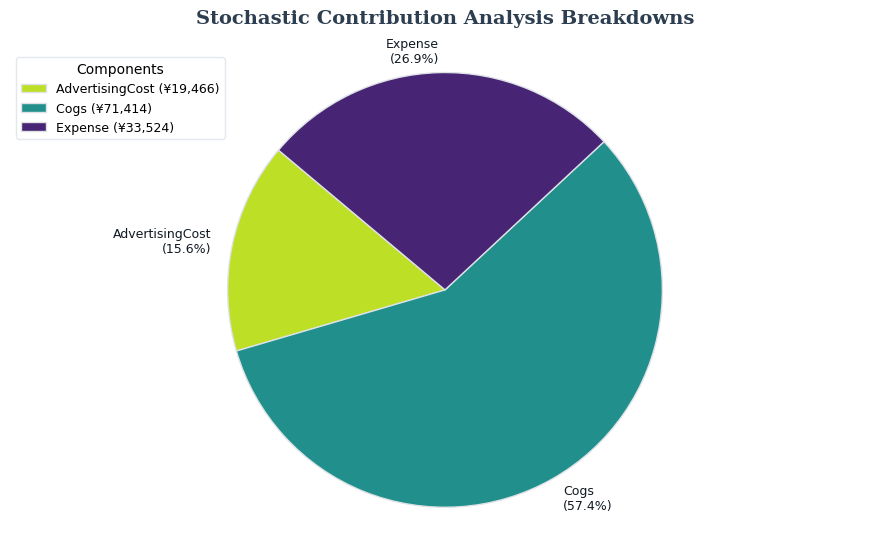

In [31]:
fig = generate_contribution_pie_chart(contributions_with_expense)
plt.show()